<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Nakamura -- Neutrino-Deuteron Cross Section Tables
---
Downloads the published neutrino-deuteron reaction cross section tables of Nakamura, Sato, Ando, Park, Myhrer, Gudkov & Kubodera, *Neutrino-deuteron reactions at solar neutrino energies*, Nucl. Phys. A707 (2002) 561 ([nucl-th/0201062](http://arXiv.org/abs/nucl-th/0201062)), from the online tables of the autors at RCNP Osaka website, and converts them into the tidy `.csv` format `tpeanuts.detector.interaction.deuteron` consumes.

Source pages:
- Tables of Neutrino (Anti-Neutrino) Deuteron Reactions Cross Sections: <br> https://www.rcnp.osaka-u.ac.jp/~anl-osk/nu-d/Netal/index.html
- Tables of Electron Momentum distributions: <br> https://www.rcnp.osaka-u.ac.jp/~anl-osk/nu-d/Netal/electron/e-spec-table/index.html

The site tabulates four reactions; only the two SNO's solar-neutrino CC/NC channels need are fetched here:

$$\text{(1) CC:}\quad \nu_e + d \to p + p + e^-, \qquad \text{(2) NC:}\quad \nu_x + d \to p + n + \nu_x.$$

(Reactions (3)/(4), the $\bar\nu_e$-induced channels, are reactor/supernova-relevant, not solar, and are not fetched.)

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Total-Cross-Sections) | **Total Cross Sections** |
| [4](#4.-CC-Electron-Spectrum) | **CC Electron Spectrum** |
| [5](#5.-Summary) | **Summary** |


## 0. Theoretical Framework
---
**Website Description**

1. `total/index.html`: total cross sections (cm$^2$) for all four reactions vs. $E_\nu$, 1.5-170 MeV -- an inline HTML table on a single page.
2. `electron/e-spec-table/e-spctr-<Enu>.html`: one page per tabulated $E_\nu$ (79 pages total, 1.5-170 MeV), each giving the CC reaction's outgoing-electron momentum distribution $d\sigma/dp_e$ vs. $(E_e, p_e)$ at that $E_\nu$. Only pages up to 20 MeV are fetched (SNO's 8B/hep solar-neutrino range, matching `detector.sno.parameters.E_NU_GRID_MEV`).

**Column identification.** The site's table headers are images (`e_e.gif`, `p_e.gif`, `dpe.gif`), not machine-readable text, so the third column's identity ($d\sigma/dp_e$ vs. $d\sigma/dE_e$) was confirmed numerically below (Section 3.2) rather than assumed: trapezoidal integration of that column *over $p_e$* exactly reproduces the independently tabulated total cross section (Section 2's table) at the same $E_\nu$, to 4 significant figures; integrating over $E_e$ instead does not. This pins the column down as $d\sigma/dp_e$, confirming the page's own "Momentum Distributions" label.

**No raw HTML is persisted.** Unlike this project's other external-data notebooks (e.g. `notebooks/external/earth/prem`), the fetched pages are small and the source URLs are fully reproducible from the naming convention above, so this notebook writes only the final parsed `.csv` outputs to `data/detector/sno/nakamura/`, not a `raw/` HTML cache.

**References**

- Nakamura, Sato, Ando, Park, Myhrer, Gudkov & Kubodera, *Neutrino-deuteron reactions at solar neutrino energies*, Nucl. Phys. A707 (2002) 561, [nucl-th/0201062](http://arXiv.org/abs/nucl-th/0201062).

The analysis treats provenance, dimensional conventions, bin measures, interpolation, and normalization as part of the physical definition of the external product; transformations are accepted only when these invariants are preserved.


## 1. Libraries

This stage evaluates libraries with explicit provenance, dimensional conventions, numerical controls, and reproducibility checks.


In [1]:
from __future__ import annotations

import re
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show

config = load_notebook_config()
OUTPUT_DIR = config.output_dir("external", "nakamura")
DATA_DIR = config.data_dir / "detector" / "sno" / "nakamura"
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://www.rcnp.osaka-u.ac.jp/~anl-osk/nu-d/Netal"
_HEADERS = {"User-Agent": "Mozilla/5.0 (tpeanuts thesis data-fetch script)"}




_SCI_RE = re.compile(r"\s*([-\d.]+)\s*\(\s*(-?\d+)\s*\)")




print(f"Output dir : {OUTPUT_DIR}")
print(f"Data dir   : {DATA_DIR}")


Output dir : v:\output\external\nakamura
Data dir   : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\sno\nakamura


## 2. Paths and Configuration

This stage evaluates paths and configuration with explicit provenance, dimensional conventions, numerical controls, and reproducibility checks.


### 2.1 Paths

Repository-relative paths identify primary-source files, metadata, generated products, and output locations.


### 2.2 Configuration

Acquisition controls, physical units, grids, interpolation rules, validation tolerances, and storage formats are fixed here before data processing.


### 2.3 Local Helpers

Notebook-local functions implement repeated acquisition, parsing, transformation, storage, and validation operations after paths and conventions are fixed.


In [ ]:
def first_nonzero_energy(col):
    nonzero = total_df.loc[total_df[col] > 0, "E_nu_MeV"]
    return float(nonzero.iloc[0]) if len(nonzero) else float("nan")

def fetch(url: str, *, retries: int = 6, timeout: float = 45.0) -> str:
    '''GET a URL as text, retrying transient failures with backoff.'''
    last_error = None
    for attempt in range(retries):
        try:
            req = urllib.request.Request(url, headers=_HEADERS)
            with urllib.request.urlopen(req, timeout=timeout) as resp:
                return resp.read().decode("utf-8", errors="replace")
        except Exception as exc:  # noqa: BLE001 -- retry any transient network error
            last_error = exc
            time.sleep(2.0 * (attempt + 1))
    raise RuntimeError(f"failed to fetch {url} after {retries} attempts") from last_error

def parse_sci(text: str) -> float:
    '''Parse the site's 'X.XXX (-NN)' notation into a float (X.XXX * 10^-NN).'''
    m = _SCI_RE.match(text)
    if not m:
        raise ValueError(f"could not parse scientific-notation cell: {text!r}")
    return float(m.group(1)) * 10.0 ** int(m.group(2))


## 3. Total Cross Sections

Fetches `total/index.html`'s single inline table: five columns, $E_\nu$ and the four reactions' total cross sections in cm$^2$. Column order on the page is $(E_\nu,\ \text{reac2},\ \text{reac4},\ \text{reac1},\ \text{reac3})$ -- reactions identified by their threshold energy matching each reaction's known $Q$-value (reac1/CC: $Q\approx1.44$ MeV; reac2,reac4/NC: $Q\approx2.22$ MeV, identical for $\nu$/$\bar\nu$ since it is a pure breakup threshold; reac3/CC-$\bar\nu$: $Q\approx4.03$ MeV) -- and reordered here into `(E_nu_MeV, sigma_cc_cm2, sigma_nc_cm2, sigma_cc_bar_cm2, sigma_nc_bar_cm2)`.

**Expected results:**<br>
- The total cross sections products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


parsed 136 rows
first nonzero E_nu per column (should match each reaction's Q-value):
  sigma_cc_cm2        : 1.50 MeV
  sigma_nc_cm2        : 2.40 MeV
  sigma_nc_bar_cm2    : 2.40 MeV
  sigma_cc_bar_cm2    : 4.20 MeV

wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\sno\nakamura\total_cross_sections.csv  shape=(136, 5)


,E_nu_MeV,sigma_nc_cm2,sigma_nc_bar_cm2,sigma_cc_cm2,sigma_cc_bar_cm2
0,1.5,0.0,0.0,4.680000e-48,0.0
1,1.6,0.0,0.0,1.147000e-46,0.0
2,1.8,0.0,0.0,1.147000e-45,0.0
3,2.0,0.0,0.0,3.670000e-45,0.0
4,2.2,0.0,0.0,7.973000e-45,0.0


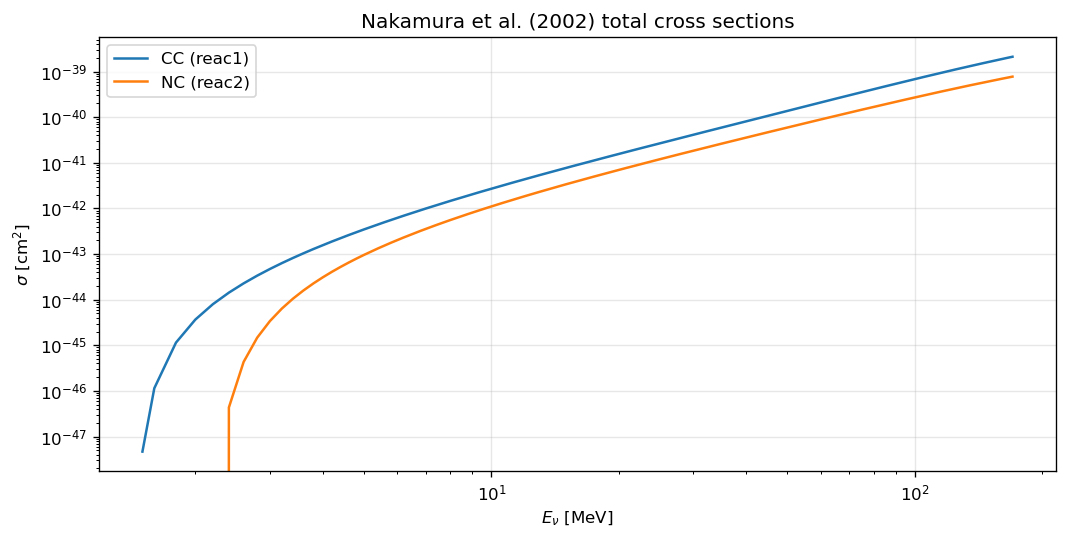

v:\output\external\nakamura\2_total_cross_sections.png


In [2]:
total_html = fetch(f"{BASE_URL}/total/index.html")

row_re = re.compile(r"<tr><th>\s*([\d.]+)</th><th>([^<]+)</th><th>([^<]+)</th><th>([^<]+)</th><th>([^<]+)</th></tr>")
rows = row_re.findall(total_html)
print(f"parsed {len(rows)} rows")

total_df = pd.DataFrame(
    [
        {
            "E_nu_MeV": float(enu),
            "sigma_nc_cm2": parse_sci(reac2),
            "sigma_nc_bar_cm2": parse_sci(reac4),
            "sigma_cc_cm2": parse_sci(reac1),
            "sigma_cc_bar_cm2": parse_sci(reac3),
        }
        for enu, reac2, reac4, reac1, reac3 in rows
    ]
).sort_values("E_nu_MeV").reset_index(drop=True)

# Reaction identification check: thresholds should match each reaction's
# known Q-value (module docstring above).

print("first nonzero E_nu per column (should match each reaction's Q-value):")
for col in ("sigma_cc_cm2", "sigma_nc_cm2", "sigma_nc_bar_cm2", "sigma_cc_bar_cm2"):
    print(f"  {col:20s}: {first_nonzero_energy(col):.2f} MeV")

total_path = DATA_DIR / "total_cross_sections.csv"
total_df.to_csv(total_path, index=False)
print(f"\nwrote {total_path}  shape={total_df.shape}")
display(total_df.head())

fig, ax = plt.subplots(figsize=(9.0, 4.6))
for col, label in [("sigma_cc_cm2", "CC (reac1)"), ("sigma_nc_cm2", "NC (reac2)")]:
    ax.plot(total_df["E_nu_MeV"], total_df[col], label=label)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$E_\nu$ [MeV]"); ax.set_ylabel(r"$\sigma$ [cm$^2$]")
ax.set_title("Nakamura et al. (2002) total cross sections")
ax.legend()
fig.tight_layout()
save_and_show("2_total_cross_sections.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


## 4. CC Electron Spectrum

This stage evaluates cc electron spectrum with explicit provenance, dimensional conventions, numerical controls, and reproducibility checks.

**Expected results:**<br>
- The cc electron spectrum products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


### 4.1 Fetch and Parse

Fetches every `e-spctr-<Enu>.html` page with $E_\nu\le20$ MeV, parsing each page's $(E_e, p_e, d\sigma/dp_e)$ table and stacking them into one tidy long-format table.

**Expected results:**<br>
- The fetch and parse products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


In [3]:
espec_index_html = fetch(f"{BASE_URL}/electron/e-spec-table/index.html")
link_re = re.compile(r"href=['\"]([^'\"]*e-spctr-([\d.]+)\.html)['\"]")
links = [(fname, float(enu)) for fname, enu in link_re.findall(espec_index_html)]
links = sorted(set(links), key=lambda x: x[1])
links = [(fname, enu) for fname, enu in links if enu <= 20.0]
print(f"{len(links)} electron-spectrum tables to fetch (E_nu <= 20 MeV)")

row_re3 = re.compile(r"<tr><th>([^<]+)</th><th>([^<]+)</th><th>([^<]+)</th></tr>")

frames = []
for i, (fname, enu) in enumerate(links):
    html = fetch(f"{BASE_URL}/electron/e-spec-table/{fname}")
    time.sleep(0.3)
    rows3 = row_re3.findall(html)
    if not rows3:
        raise RuntimeError(f"no data rows parsed from {fname}")
    frame = pd.DataFrame(
        [
            {
                "E_nu_MeV": enu,
                "E_e_MeV": parse_sci(ee),
                "p_e_MeV": parse_sci(pe),
                "dsigma_dpe_cm2_per_MeV": parse_sci(dpe),
            }
            for ee, pe, dpe in rows3
        ]
    )
    frames.append(frame)
    if (i + 1) % 10 == 0 or i == len(links) - 1:
        print(f"  fetched {i + 1}/{len(links)}: E_nu={enu:g} MeV, {len(frame)} rows")

electron_df = pd.concat(frames, ignore_index=True)
print(f"\ntotal rows: {len(electron_df)}")
display(electron_df.head())


64 electron-spectrum tables to fetch (E_nu <= 20 MeV)


  fetched 10/64: E_nu=3.2 MeV, 218 rows


  fetched 20/64: E_nu=5.2 MeV, 218 rows


  fetched 30/64: E_nu=7.2 MeV, 218 rows


  fetched 40/64: E_nu=9.2 MeV, 218 rows


  fetched 50/64: E_nu=13 MeV, 218 rows


  fetched 60/64: E_nu=18 MeV, 218 rows


  fetched 64/64: E_nu=20 MeV, 218 rows

total rows: 13951


,E_nu_MeV,E_e_MeV,p_e_MeV,dsigma_dpe_cm2_per_MeV
0,1.5,0.510999,0.000000,0.000000e+00
1,1.5,0.511001,0.001227,1.877540e-49
2,1.5,0.511028,0.005441,8.324969e-49
3,1.5,0.511090,0.009656,1.486162e-48
4,1.5,0.511143,0.012109,1.885827e-48


### 4.2 Validate: Column Identity and Normalization

Confirms the third column is $d\sigma/dp_e$ (not $d\sigma/dE_e$): for each tabulated $E_\nu$, trapezoidal integration over $p_e$ should reproduce Section 2's independently tabulated total CC cross section at that energy.

**Expected results:**<br>
- The validate: column identity and normalization products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


C:\Users\juanr\AppData\Local\Temp\ipykernel_52036\929493879.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_over_pe = np.trapz(group["dsigma_dpe_cm2_per_MeV"], group["p_e_MeV"])
C:\Users\juanr\AppData\Local\Temp\ipykernel_52036\929493879.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_over_Ee = np.trapz(group["dsigma_dpe_cm2_per_MeV"], group["E_e_MeV"])


,rel_err_pe,rel_err_Ee
count,61.000000,61.000000
mean,0.000376,0.050375
std,0.000295,0.133982
min,0.000001,0.000029
25%,0.000143,0.000827
50%,0.000292,0.004948
75%,0.000622,0.021959
max,0.001172,0.758941


max rel_err integrating over p_e: 0.1172%
max rel_err integrating over E_e: 75.8941%

wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\sno\nakamura\cc_electron_spectrum.csv  shape=(13951, 4)


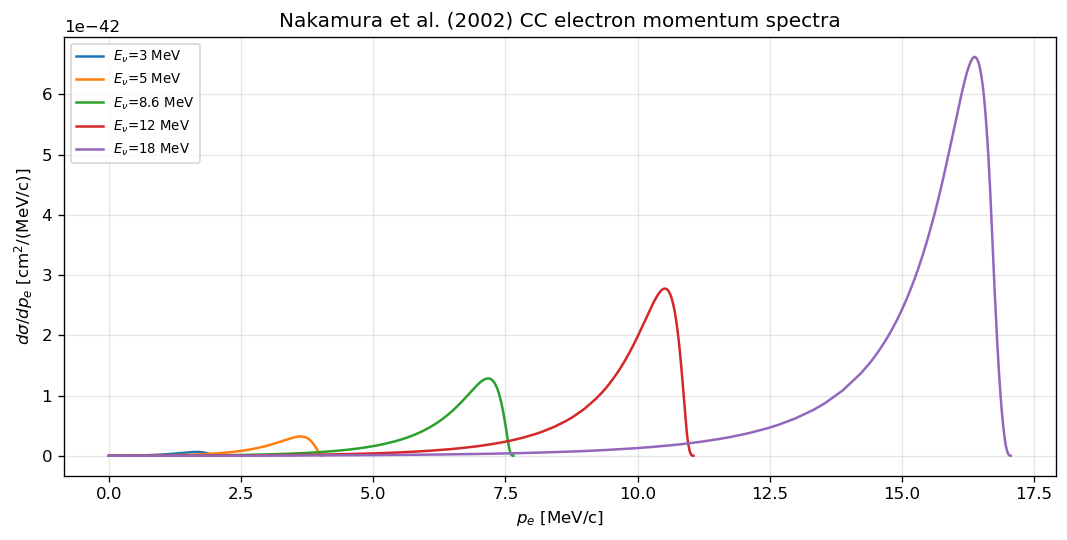

v:\output\external\nakamura\3_cc_electron_spectra.png


In [4]:
check_rows = []
for enu, group in electron_df.groupby("E_nu_MeV"):
    group = group.sort_values("p_e_MeV")
    integral_over_pe = np.trapz(group["dsigma_dpe_cm2_per_MeV"], group["p_e_MeV"])
    integral_over_Ee = np.trapz(group["dsigma_dpe_cm2_per_MeV"], group["E_e_MeV"])
    ref = total_df.loc[np.isclose(total_df["E_nu_MeV"], enu), "sigma_cc_cm2"]
    if len(ref) == 0:
        continue
    ref = float(ref.iloc[0])
    check_rows.append(
        {
            "E_nu_MeV": enu,
            "integral_over_pe": integral_over_pe,
            "integral_over_Ee": integral_over_Ee,
            "reference_total": ref,
            "rel_err_pe": abs(integral_over_pe - ref) / ref if ref > 0 else float("nan"),
            "rel_err_Ee": abs(integral_over_Ee - ref) / ref if ref > 0 else float("nan"),
        }
    )
check_df = pd.DataFrame(check_rows)
display(check_df.describe()[["rel_err_pe", "rel_err_Ee"]])
print(f"max rel_err integrating over p_e: {check_df['rel_err_pe'].max():.4%}")
print(f"max rel_err integrating over E_e: {check_df['rel_err_Ee'].max():.4%}")

electron_path = DATA_DIR / "cc_electron_spectrum.csv"
electron_df.to_csv(electron_path, index=False)
print(f"\nwrote {electron_path}  shape={electron_df.shape}")

fig, ax = plt.subplots(figsize=(9.0, 4.6))
for enu in (3.0, 5.0, 8.6, 12.0, 18.0):
    sub = electron_df.loc[np.isclose(electron_df["E_nu_MeV"], enu)].sort_values("p_e_MeV")
    if len(sub):
        ax.plot(sub["p_e_MeV"], sub["dsigma_dpe_cm2_per_MeV"], label=f"$E_\\nu$={enu:g} MeV")
ax.set_xlabel(r"$p_e$ [MeV/c]"); ax.set_ylabel(r"$d\sigma/dp_e$ [cm$^2$/(MeV/c)]")
ax.set_title("Nakamura et al. (2002) CC electron momentum spectra")
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("3_cc_electron_spectra.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


## 5. Summary
---
Wrote two files to `data/detector/sno/nakamura/`:

- `total_cross_sections.csv` -- $(E_\nu, \sigma_{CC}, \sigma_{NC}, \sigma_{CC,\bar\nu}, \sigma_{NC,\bar\nu})$, 1.5-170 MeV.
- `cc_electron_spectrum.csv` -- $(E_\nu, E_e, p_e, d\sigma_{CC}/dp_e)$, 1.5-20 MeV, validated against the total table to better than the site's own quoted 0.1%-1% numerical accuracy.

`tpeanuts.detector.interaction.deuteron` consumes both files directly (interpolated, not refit), replacing its previous illustrative threshold-power-law placeholder with this real published calculation.

**Expected results:**<br>
- The summary products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.
